load the required library

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [98]:
netflix_df = pd.read_csv('/content/netflix_titles.csv.zip')

In [99]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [100]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


 Data cleaning part

count the missing vlaues and the isnull value

In [101]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


handle of this 2 columns

In [102]:
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [103]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,831
date_added,10
release_year,0
rating,4
duration,3


handle the ['country'] columns

In [104]:
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [105]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


handle the 3 columns 'date_added','rating'and'duration'

In [106]:
netflix_df.dropna(subset=['date_added','rating','duration'],inplace=True)

In [107]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


date type Incinsistency in the 'date_added' columns

In [108]:
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'],format = 'mixed',dayfirst = False)

Feature Engineering

In [109]:
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

final checking after handlaing missing value an inconsistency

In [110]:
print('Missing value after cleaning')
print(netflix_df.isnull().sum())
print('\nData types after tranformation:')
print(netflix_df.dtypes)

Missing value after cleaning
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after tranformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


EDA-> exporatory data analysis

In [111]:
# columnas type

type_counts = netflix_df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


pie chart

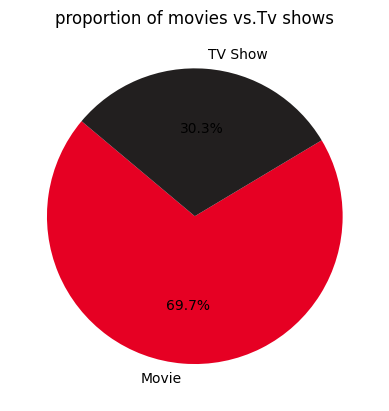

In [112]:
plt.pie(type_counts,labels = type_counts.index,autopct='%1.1f%%',startangle = 140,colors = ['#e60023','#221f1f'])
plt.title('proportion of movies vs.Tv shows')
plt.ylabel('')
plt.savefig('proportion of movies vs.Tv shows.png')
plt.show()

In [113]:
content_over_time = netflix_df.groupby(['year_added','type']).size().unstack().fillna(0)
print(content_over_time)

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


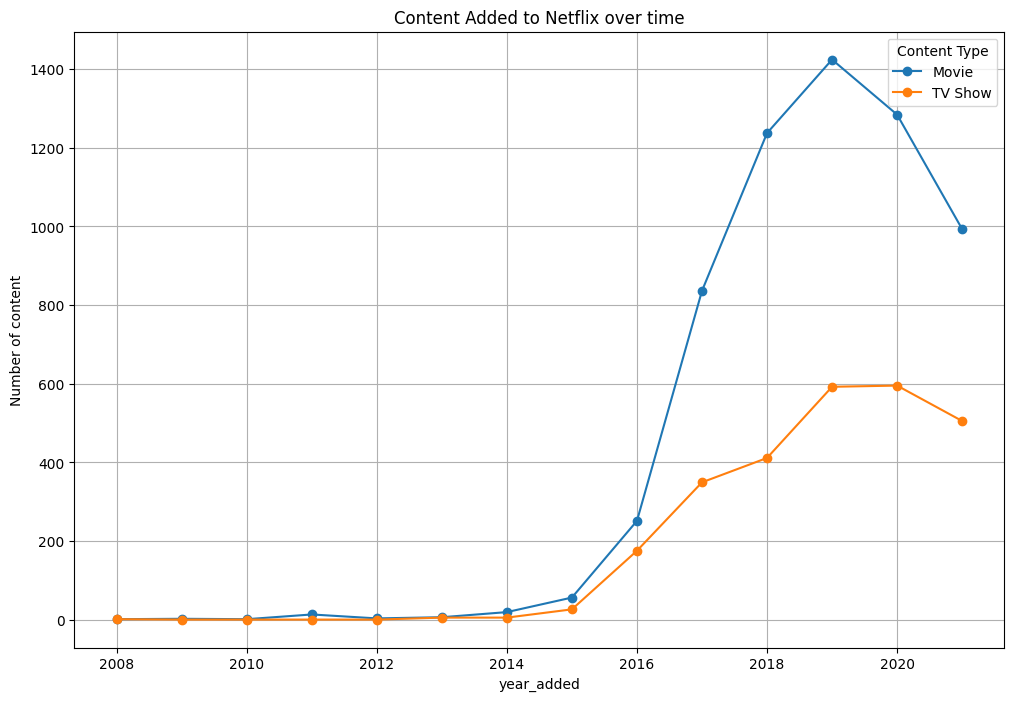

In [114]:
content_over_time.plot(kind='line',marker= 'o',figsize=(12,8))
plt.title('Content Added to Netflix over time')
plt.xlabel('year_added')
plt.ylabel('Number of content')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

what are the most popular in genre?

In [115]:
genre_temp = netflix_df.copy()
genre_temp['genre_list'] = genre_temp['listed_in'].str.split(',').apply(lambda x: [g.strip() for g in x])
genre = genre_temp.explode('genre_list')
genre = genre.rename(columns={'genre_list': 'genre'})
genre

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Dramas
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,International Movies


In [116]:
genre = genre.reset_index(drop=True)

get the top 15 genre netflix

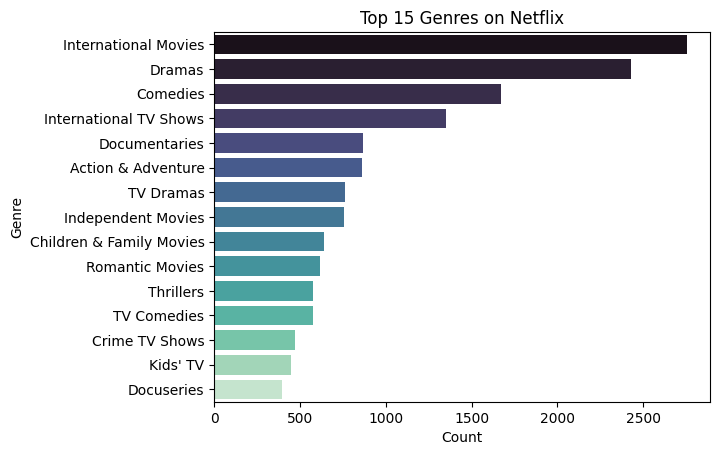

In [117]:
top_genres_counts = genre['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre','count']
top_genres_counts = top_genres_counts.head(15)
sns.barplot(y='genre',x='count', data=top_genres_counts ,palette='mako', hue='genre',legend=False)
plt.xlabel('Count')
plt.ylabel('Genre')
plt.title('Top 15 Genres on Netflix')
plt.savefig('top 15 genre records')
plt.show()

separate movies and tv shows

Filttering data

In [118]:
movie_df = netflix_df[netflix_df['type']=='Movie'].copy()
tv_show_df = netflix_df[netflix_df['type']=='TV Show'].copy()

In [119]:
movie_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016,3
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1


In [120]:
tv_show_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,Unknown,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2018-05-01,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...,2018,5
8796,s8797,TV Show,Yunus Emre,Unknown,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves...",2017,1
8797,s8798,TV Show,Zak Storm,Unknown,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...,2018,9
8800,s8801,TV Show,Zindagi Gulzar Hai,Unknown,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre...",2016,12


/tmp/ipykernel_2743/580760691.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=tv_show_seasons_counts.index, y=tv_show_seasons_counts.values, palette='viridis', legend=False).set(


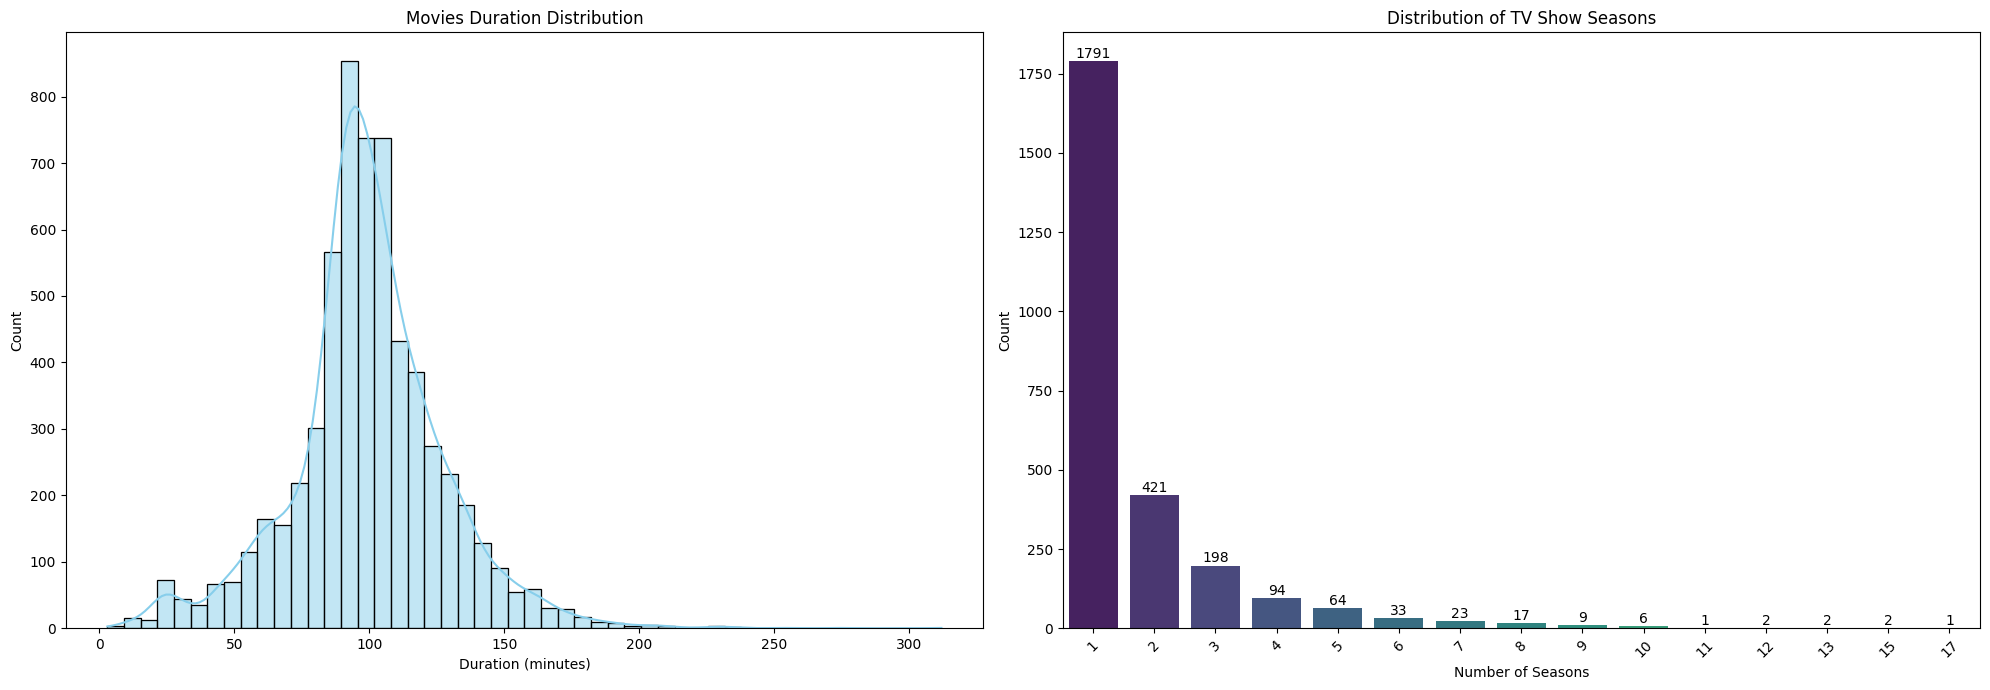

In [121]:
movie_df['duration_min'] = movie_df['duration'].str.replace(' min', '').astype(int)
tv_show_df['Seasons'] = tv_show_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.histplot(ax=axes[0], data=movie_df, x='duration_min', bins=50, kde=True, color='skyblue').set(
    title='Movies Duration Distribution', xlabel='Duration (minutes)', ylabel='Count'
)

tv_show_seasons_counts = tv_show_df['Seasons'].value_counts().sort_index()
sns.barplot(ax=axes[1], x=tv_show_seasons_counts.index, y=tv_show_seasons_counts.values, palette='viridis', legend=False).set(
    title='Distribution of TV Show Seasons', xlabel='Number of Seasons', ylabel='Count'
)

for index, value in enumerate(tv_show_seasons_counts.values):
    axes[1].text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

wheb does the conent coemfrom?

In [122]:
countries = netflix_df.assign(country=netflix_df['country'].str.split(',')).explode('country')

In [123]:
top_countries_counts =  countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country','count']

print(top_countries_counts)

            country  count
0     United States   4031
1             India   1008
2    United Kingdom    627
3     United States    479
4            Canada    271
..              ...    ...
192          Panama      1
193         Namibia      1
194          Uganda      1
195    East Germany      1
196      Montenegro      1

[197 rows x 2 columns]


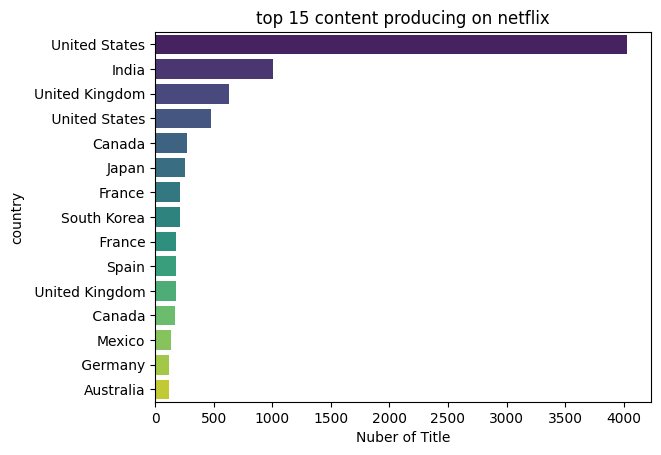

In [124]:
top_countries_counts = top_countries_counts.head(15)
sns.barplot(y='country',x='count',data=top_countries_counts,palette='viridis',hue='country',legend=False)

plt.title('top 15 content producing on netflix')
plt.xlabel('Nuber of Title')
plt.ylabel('country')
plt.savefig('top 15 conten producing on netflix.png')
plt.show()


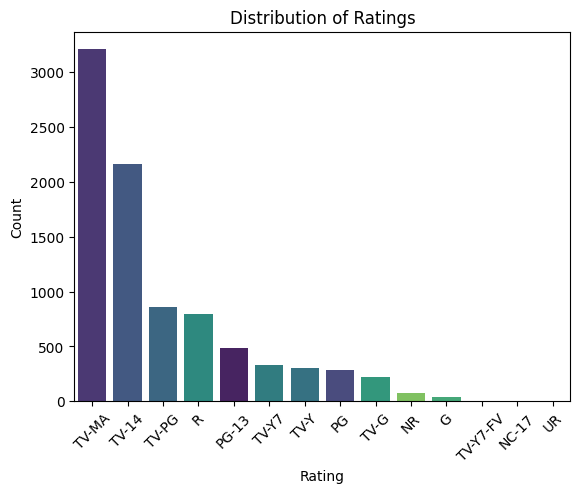

In [125]:
sns.countplot(x = 'rating',data=netflix_df,order=netflix_df ['rating'].value_counts().index,palette = 'viridis',hue='rating', legend=False)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

Feature Engineering

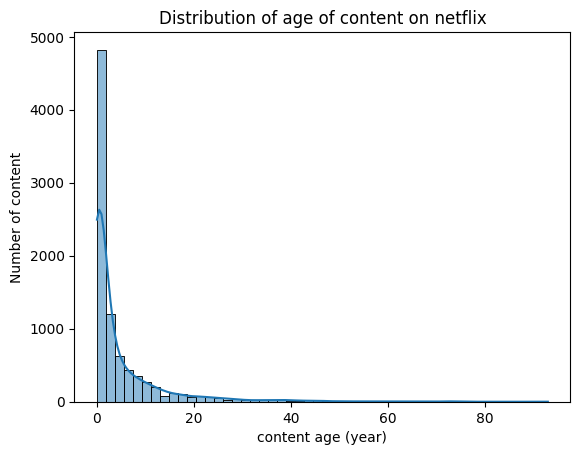

In [126]:
netflix_df['age_on_netflix'] = netflix_df['year_added']-netflix_df['release_year']

#fillter out potertail errors

content_age = netflix_df[netflix_df['age_on_netflix']>=0]

sns.histplot(data = content_age,x='age_on_netflix',bins=50,kde=True)

plt.title('Distribution of age of content on netflix')
plt.xlabel('content age (year)')
plt.ylabel('Number of content')
plt.show()


multivoriate Analysis

/tmp/ipykernel_2743/3641550846.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = genres_movies,x='genre',y='duration_min',palette = 'pastel',legend=False)


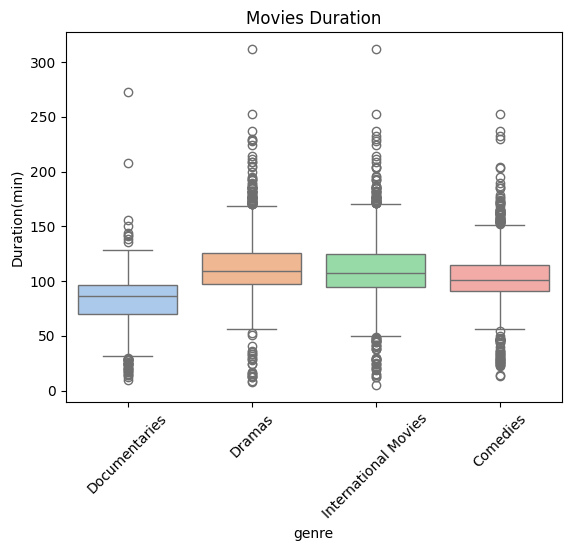

In [128]:
top_genres = genre['genre'].value_counts().head(5).index.tolist()

top_genres = [g.strip() for g in top_genres]
genres_movies = genre[(genre['type']=='Movie')&(genre['genre'].isin(top_genres))].copy()
genres_movies['duration_min']=genres_movies['duration'].str.replace('min',' ').astype(int)

sns.boxplot(data = genres_movies,x='genre',y='duration_min',palette = 'pastel',legend=False)
plt.title('Movies Duration')
plt.xlabel('genre')
plt.ylabel('Duration(min)')
plt.xticks(rotation=45)
plt.show()

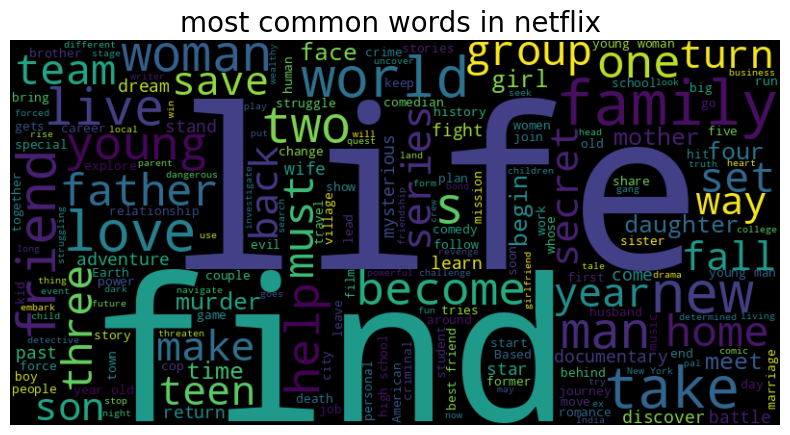

In [144]:
# world cloud from the  content description

text = ''.join(netflix_df['description'])

# creat and genrate the cloud image

wordcloud = WordCloud(width=800,height=400,background_color= 'black').generate(text)

# display the background image

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('most common words in netflix ', fontsize =20)
plt.savefig('most common words in netflix data.png')
plt.show()